## Radiation > plot_ICS_angularDist + plotScatteringPhoton + photonEnergySpectrum

In [1]:
import numpy as np
from scipy.integrate import quad
import matplotlib.pyplot as plt
import torch

In [19]:
# before
class Radiation:
    e = 1.602176634e-19  # Elementary charge (C) [CODATA 2018]
    MeV_to_J = 1.602176634e-13  # Conversion factor from MeV to Joules [CODATA 2018]
    NA = 6.02214076e23  # Avogadro's number
    epsilon_0 = 8.854187817e-12  # Vacuum permittivity (F/m)
    me = 9.10938356e-31  # Electron mass (kg)
    m_p = 1.67262192595e-27  # Proton Mass (kg)
    c = 299792458.0  # Speed of light (m/s)
    r_e = e**2 / (4 * np.pi * epsilon_0 * me * c**2)  # Classical electron radius [m]
    h = 6.62607015e-34        # Planck constant (J·s)
    me_c2_J = me * c**2             # Electron rest energy [J]


    def __init__(self, eMev = 45, lambda_L_um = 3, theta_vals = 1000) -> None:
        self.E_e_MeV = eMev  # Electron energy [MeV]
        self.gamma = self.E_e_MeV * 1e6 * self.e  / self.me_c2_J         # Lorentz factor
        self.theta_vals = np.linspace(0, 5/self.gamma, theta_vals)
        self.theta_mrad = self.theta_vals * 1e3

        self.lambda_L = lambda_L_um * 1e-6                  # Laser wavelength [m]
        self.E_gamma_L = self.h * self.c / self.lambda_L                   # Photon energy [J]
    def plot_ICS_angularDist(self,E_thresh_eV = 1e4):

        # Threshold for desired photon energy [eV]
        E_thresh_J = E_thresh_eV * self.e

        # Find theta_max where E_gamma(theta) = E_thresh
        # For relativistic beams, approximate small angle solution:
        theta_thresh_rad = np.sqrt((4 * self.gamma**2 * self.E_gamma_L / E_thresh_J - 1 - 4 * self.gamma * self.E_gamma_L / self.me_c2_J) / self.gamma**2)
        theta_thresh_mrad = theta_thresh_rad * 1e3


        sigma_T = (8 * np.pi / 3) * self.r_e**2  # # Thomson scattering cross section [m^2]
        # Compute differential cross section (Thomson) * sin(theta)
        d_sigma_vals = 0.5 * self.r_e**2 * (1 + np.cos(self.theta_vals)**2) * np.sin(self.theta_vals)
        # Normalize to total cross section
        d_sigma_normalized = d_sigma_vals / sigma_T

        # Plot
        plt.figure(figsize=(8,5))
        plt.plot(self.theta_mrad, d_sigma_normalized, label=r"$\frac{1}{\sigma_T}\frac{d\sigma}{d\Omega} \cdot \sin\theta$", color='blue')
        plt.axvline(theta_thresh_mrad, color='red', linestyle='--', label="10 keV cutoff")
        plt.fill_between(self.theta_mrad, d_sigma_normalized, where=(self.theta_mrad <= theta_thresh_mrad), color='blue', alpha=0.3, label="E ≥ 10 keV")
        plt.xlabel("Scattering angle θ [mrad]")
        plt.ylabel("Normalized angular distribution")
        plt.title("ICS Angular Distribution (to be fixed)")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    def plotScatteringPhoton(self, E_thresh_eV = 1e4):
        # Threshold for desired photon energy [eV]
        E_thresh_J = E_thresh_eV * self.e

        E_gamma_theta_J = (4 * self.gamma**2 * self.E_gamma_L) / (1 + 4 * self.gamma * self.E_gamma_L / self.me_c2_J + self.gamma**2 * self.theta_vals**2)
        E_gamma_theta_keV = E_gamma_theta_J / self.e / 1e3  # convert to keV

        theta_1_over_gamma_mrad = (1 / self.gamma) * 1e3

        theta_thresh_rad = np.sqrt((4 * self.gamma**2 * self.E_gamma_L / E_thresh_J - 1 - 4 * self.gamma * self.E_gamma_L / self.me_c2_J) / self.gamma**2)
        theta_thresh_mrad = theta_thresh_rad * 1e3

        plt.figure(figsize=(8,5))
        plt.plot(self.theta_mrad, E_gamma_theta_keV, label=r"$E_\gamma(\theta)$")
        plt.axvline(theta_1_over_gamma_mrad, color='green', linestyle='--', label=r"$1/\gamma$")
        plt.axvline(theta_thresh_mrad, color='red', linestyle='--', label="10 keV cutoff")
        plt.axhline(10, color='gray', linestyle=':', linewidth=0.8)
        plt.xlabel("Scattering angle θ [mrad]")
        plt.ylabel("Scattered photon energy [keV]")
        plt.title("ICS Photon Energy vs Scattering Angle")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    def photonEnergySpectrum(self):
        # Compute photon energy [keV] vs angle
        E_gamma_vals_keV = (4 * self.gamma**2 * self.E_gamma_L) / (1 + 4 * self.gamma * self.E_gamma_L / self.me_c2_J + self.gamma**2 * self.theta_vals**2)
        E_gamma_vals_keV /= (self.e * 1e3)  # Convert to keV

        dtheta = self.theta_vals[1] - self.theta_vals[0]
        # Compute weight: dσ/dΩ * sinθ * dθ (differential number of photons)
        d_sigma_vals = 0.5 * self.r_e**2 * (1 + np.cos(self.theta_vals)**2) * np.sin(self.theta_vals)
        weights = d_sigma_vals * dtheta  # dΩ slice

        # Histogram to build energy distribution
        E_bins = np.linspace(0, np.max(E_gamma_vals_keV), 300)
        hist_vals, bin_edges = np.histogram(E_gamma_vals_keV, bins=E_bins, weights=weights)
        E_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

        # Normalize to unit area (optional)
        hist_vals /= np.sum(hist_vals * np.diff(E_bins))

        plt.figure(figsize=(8,5))
        plt.plot(E_centers, hist_vals, label=r"$\frac{1}{\sigma_T} \frac{d\sigma}{dE_\gamma}$", color='blue')
        plt.axvline(10, color='red', linestyle='--', label="10 keV threshold")
        plt.fill_between(E_centers, hist_vals, where=(E_centers >= 10), alpha=0.3, color='blue', label="E ≥ 10 keV")
        plt.xlabel("Photon energy [keV]")
        plt.ylabel("Normalized photon distribution")
        plt.title("ICS Photon Energy Spectrum: to be fixed")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

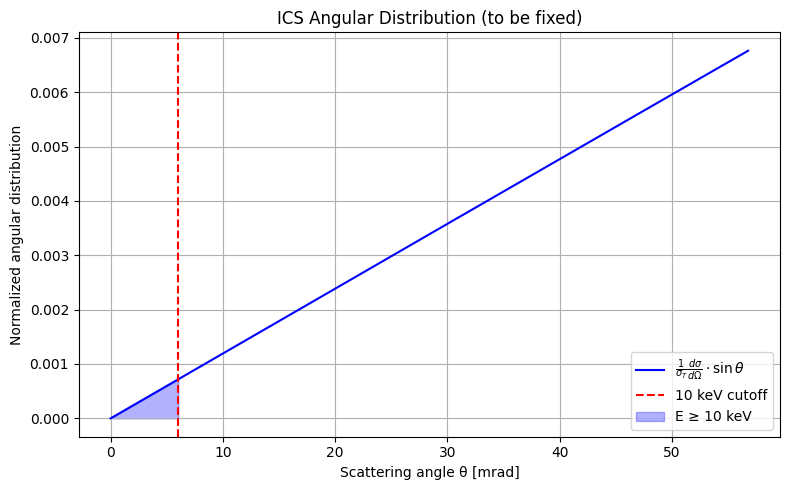

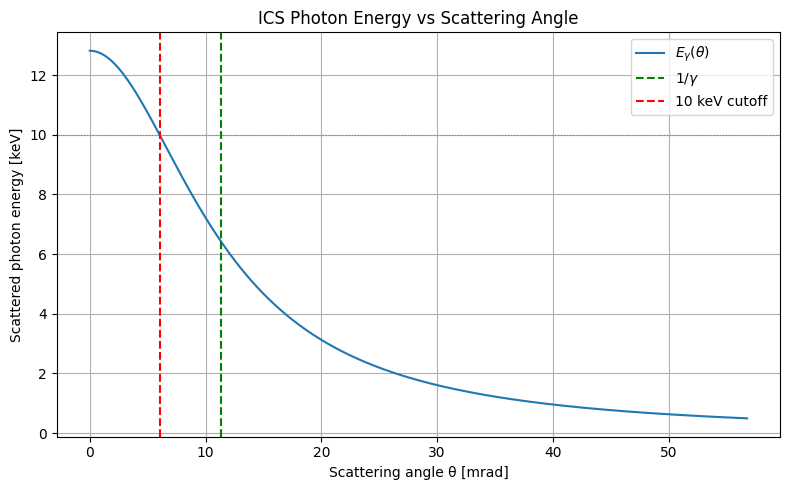

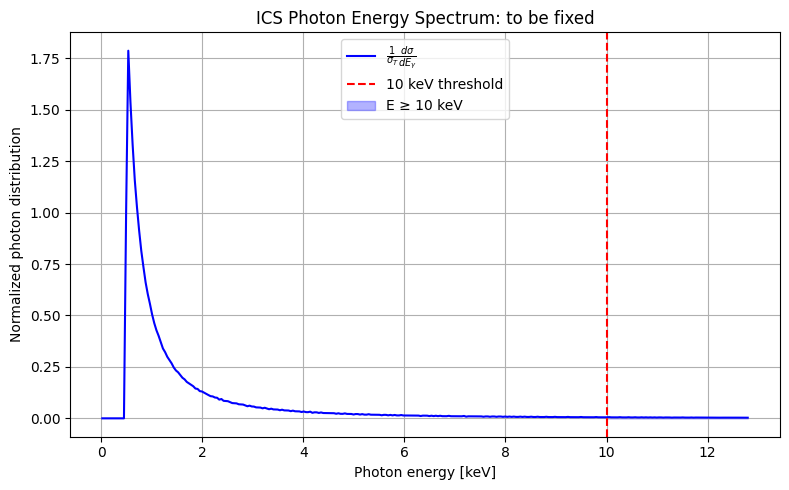

In [20]:
obj = Radiation(45, theta_vals=5000)
obj.plot_ICS_angularDist()
obj.plotScatteringPhoton()
obj.photonEnergySpectrum()

In [23]:
# after
class Radiation:
    e = 1.602176634e-19  # Elementary charge (C) [CODATA 2018]
    MeV_to_J = 1.602176634e-13  # Conversion factor from MeV to Joules [CODATA 2018]
    NA = 6.02214076e23  # Avogadro's number
    epsilon_0 = 8.854187817e-12  # Vacuum permittivity (F/m)
    me = 9.10938356e-31  # Electron mass (kg)
    m_p = 1.67262192595e-27  # Proton Mass (kg)
    c = 299792458.0  # Speed of light (m/s)
    r_e = e**2 / (4 * torch.pi * epsilon_0 * me * c**2)  # Classical electron radius [m]
    h = 6.62607015e-34        # Planck constant (J·s)
    me_c2_J = me * c**2             # Electron rest energy [J]


    def __init__(self, eMev = 45, lambda_L_um = 3, theta_vals = 1000) -> None:
        self.E_e_MeV = torch.tensor(eMev)  # Electron energy [MeV]
        self.gamma = self.E_e_MeV * 1e6 * self.e  / self.me_c2_J        # Lorentz factor
        self.theta_vals = torch.linspace(0, 5/self.gamma, theta_vals)
        self.theta_mrad = self.theta_vals * 1e3

        self.lambda_L = torch.tensor(lambda_L_um * 1e-6)                  # Laser wavelength [m]
        self.E_gamma_L = self.h * self.c / self.lambda_L                  # Photon energy [J]
    def plot_ICS_angularDist(self,E_thresh_eV = 1e4):

        # Threshold for desired photon energy [eV]
        E_thresh_J = E_thresh_eV * self.e

        # Find theta_max where E_gamma(theta) = E_thresh
        # For relativistic beams, approximate small angle solution:
        theta_thresh_rad = torch.sqrt((4 * self.gamma**2 * self.E_gamma_L / E_thresh_J - 1 - 4 * self.gamma * self.E_gamma_L / self.me_c2_J) / self.gamma**2)
        theta_thresh_mrad = theta_thresh_rad * 1e3


        sigma_T = (8 * torch.pi / 3) * self.r_e**2  # # Thomson scattering cross section [m^2]
        # Compute differential cross section (Thomson) * sin(theta)
        d_sigma_vals = 0.5 * self.r_e**2 * (1 + torch.cos(self.theta_vals)**2) * torch.sin(self.theta_vals)
        # Normalize to total cross section
        d_sigma_normalized = d_sigma_vals / sigma_T

        # Plot
        plt.figure(figsize=(8,5))
        plt.plot(self.theta_mrad, d_sigma_normalized, label=r"$\frac{1}{\sigma_T}\frac{d\sigma}{d\Omega} \cdot \sin\theta$", color='blue')
        plt.axvline(theta_thresh_mrad, color='red', linestyle='--', label="10 keV cutoff")
        plt.fill_between(self.theta_mrad, d_sigma_normalized, where=(self.theta_mrad <= theta_thresh_mrad), color='blue', alpha=0.3, label="E ≥ 10 keV")
        plt.xlabel("Scattering angle θ [mrad]")
        plt.ylabel("Normalized angular distribution")
        plt.title("ICS Angular Distribution (to be fixed)")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()


    def plotScatteringPhoton(self, E_thresh_eV = 1e4):
        # Threshold for desired photon energy [eV]
        E_thresh_J = E_thresh_eV * self.e

        E_gamma_theta_J = (4 * self.gamma**2 * self.E_gamma_L) / (1 + 4 * self.gamma * self.E_gamma_L / self.me_c2_J + self.gamma**2 * self.theta_vals**2)
        E_gamma_theta_keV = E_gamma_theta_J / self.e / 1e3  # convert to keV

        theta_1_over_gamma_mrad = (1 / self.gamma) * 1e3

        theta_thresh_rad = torch.sqrt((4 * self.gamma**2 * self.E_gamma_L / E_thresh_J - 1 - 4 * self.gamma * self.E_gamma_L / self.me_c2_J) / self.gamma**2)
        theta_thresh_mrad = theta_thresh_rad * 1e3

        plt.figure(figsize=(8,5))
        plt.plot(self.theta_mrad, E_gamma_theta_keV, label=r"$E_\gamma(\theta)$")
        plt.axvline(theta_1_over_gamma_mrad, color='green', linestyle='--', label=r"$1/\gamma$")
        plt.axvline(theta_thresh_mrad, color='red', linestyle='--', label="10 keV cutoff")
        plt.axhline(10, color='gray', linestyle=':', linewidth=0.8)
        plt.xlabel("Scattering angle θ [mrad]")
        plt.ylabel("Scattered photon energy [keV]")
        plt.title("ICS Photon Energy vs Scattering Angle")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    def photonEnergySpectrum(self):
        # Compute photon energy [keV] vs angle
        E_gamma_vals_keV = (4 * self.gamma**2 * self.E_gamma_L) / (1 + 4 * self.gamma * self.E_gamma_L / self.me_c2_J + self.gamma**2 * self.theta_vals**2)
        E_gamma_vals_keV /= (self.e * 1e3)  # Convert to keV

        dtheta = self.theta_vals[1] - self.theta_vals[0]
        # Compute weight: dσ/dΩ * sinθ * dθ (differential number of photons)
        d_sigma_vals = 0.5 * self.r_e**2 * (1 + torch.cos(self.theta_vals)**2) * torch.sin(self.theta_vals)
        weights = d_sigma_vals * dtheta  # dΩ slice

        # Histogram to build energy distribution
        E_bins = torch.linspace(0, torch.max(E_gamma_vals_keV), 300)
        hist_vals, bin_edges = torch.histogram(E_gamma_vals_keV.cpu(),
                                           bins=E_bins.cpu(),
                                           weight=weights.cpu())
        E_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

        # Normalize to unit area (optional)
        hist_vals /= torch.sum(hist_vals * torch.diff(E_bins))

        plt.figure(figsize=(8,5))
        plt.plot(E_centers, hist_vals, label=r"$\frac{1}{\sigma_T} \frac{d\sigma}{dE_\gamma}$", color='blue')
        plt.axvline(10, color='red', linestyle='--', label="10 keV threshold")
        plt.fill_between(E_centers, hist_vals, where=(E_centers >= 10), alpha=0.3, color='blue', label="E ≥ 10 keV")
        plt.xlabel("Photon energy [keV]")
        plt.ylabel("Normalized photon distribution")
        plt.title("ICS Photon Energy Spectrum: to be fixed")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

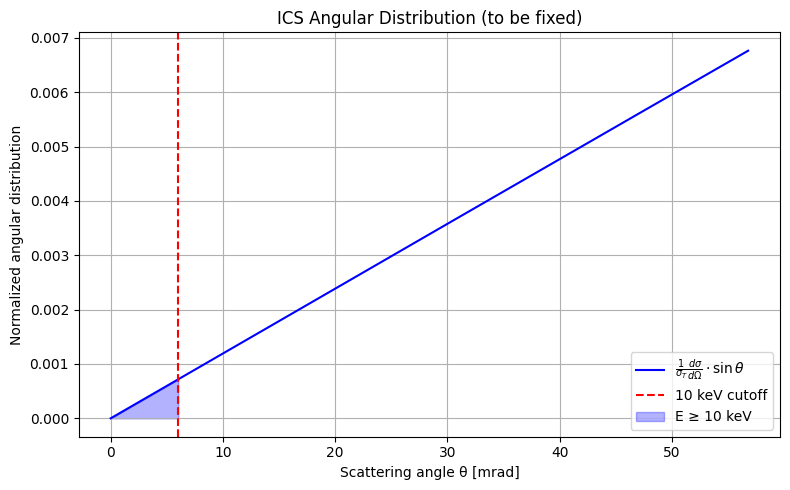

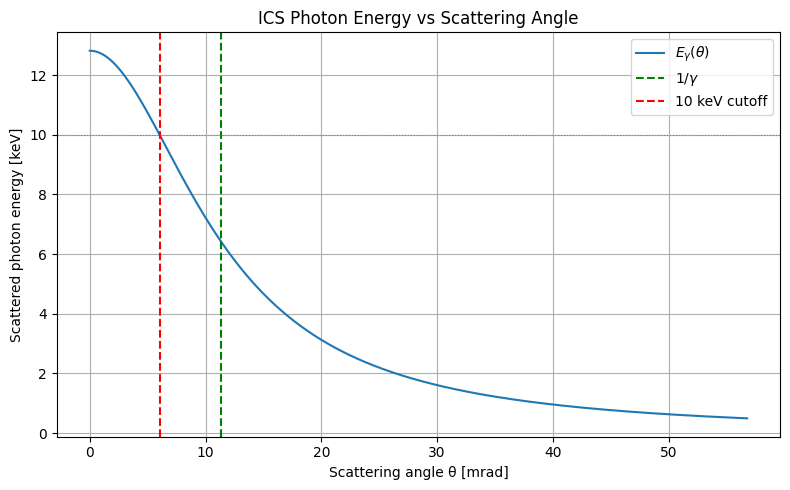

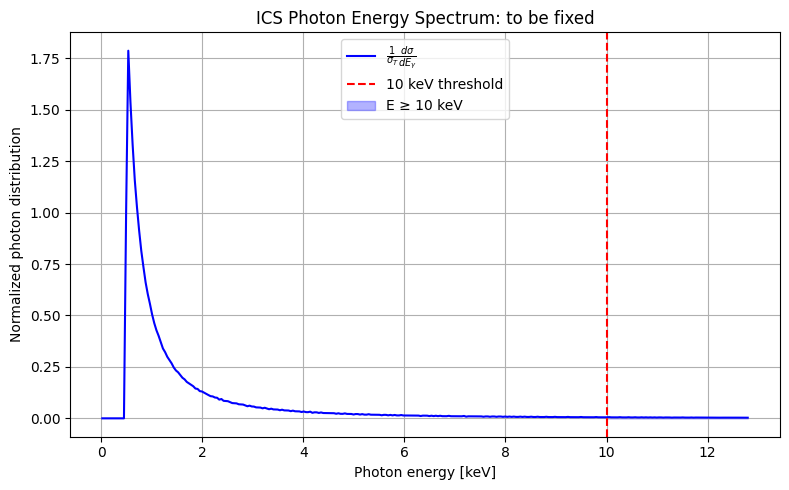

In [24]:
obj = Radiation(45, theta_vals=5000)
obj.plot_ICS_angularDist()
obj.plotScatteringPhoton()
obj.photonEnergySpectrum()